Mounted at /content/drive
Total pairs: 50 | Train: 40 | Test: 10

Loading training images into RAM...
  Train 40/40 | shape: (128, 128, 4)
Loading test images into RAM...
  Test 10/10 | shape: (128, 128, 4)
Train X: (40, 128, 128, 4) | Train Y: (40, 256, 256, 3)
Test  X: (10, 128, 128, 4)  | Test  Y: (10, 256, 256, 3)

Model params: 2,028,807
Input shape:  (None, 128, 128, 4)
Output shape: (None, 256, 256, 3)

Training started...
Epoch  10/100 | Train: 0.2471 | Val: 0.1141 | Elapsed: 0.4m | ETA: 3.5m
Epoch  20/100 | Train: 0.1408 | Val: 0.1040 | Elapsed: 0.4m | ETA: 1.7m
Epoch  30/100 | Train: 0.1193 | Val: 0.0870 | Elapsed: 0.5m | ETA: 1.1m
Epoch  40/100 | Train: 0.1035 | Val: 0.0753 | Elapsed: 0.5m | ETA: 0.7m
Epoch  50/100 | Train: 0.0883 | Val: 0.0661 | Elapsed: 0.5m | ETA: 0.5m
Epoch  60/100 | Train: 0.0769 | Val: 0.0701 | Elapsed: 0.6m | ETA: 0.4m
Epoch  70/100 | Train: 0.0732 | Val: 0.0618 | Elapsed: 0.6m | ETA: 0.3m
Epoch  80/100 | Train: 0.0696 | Val: 0.0631 | Elapsed: 0.6m | 

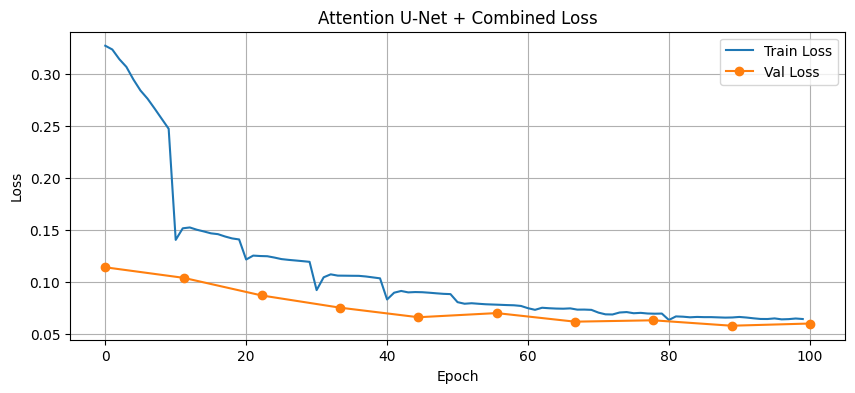

Loss curve saved!


In [ ]:

import subprocess
subprocess.run(['pip', 'install', 'rawpy', 'tensorflow', '-q'])

import os, time, rawpy
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# ── 2. Pair images ──────────────────────────────────────────
short_path  = '/content/drive/MyDrive/short'
long_path   = '/content/drive/MyDrive/long'
short_files = sorted(os.listdir(short_path))
long_files  = sorted(os.listdir(long_path))

pairs = []
for sf in short_files:
    sid = sf[:5]
    for lf in long_files:
        if lf[:5] == sid:
            pairs.append((os.path.join(short_path, sf),
                          os.path.join(long_path,  lf)))
            break

train_pairs = pairs[:40]
test_pairs  = pairs[40:]
print(f"Total pairs: {len(pairs)} | Train: {len(train_pairs)} | Test: {len(test_pairs)}")

# ── 3. Data loader ──────────────────────────────────────────
def pack_raw(raw):
    im = raw.raw_image_visible.astype(np.float32)
    im = np.maximum(im - 512, 0) / (16383 - 512)
    im = np.expand_dims(im, axis=2)
    H, W = im.shape[:2]
    return np.concatenate([im[0:H:2, 0:W:2],
                           im[0:H:2, 1:W:2],
                           im[1:H:2, 1:W:2],
                           im[1:H:2, 0:W:2]], axis=2)

def load_pair(sp, lp, ps=256):
    se    = float(os.path.basename(sp).split('_')[-1][:-5])
    le    = float(os.path.basename(lp).split('_')[-1][:-5])
    ratio = min(le / se, 300)

    raw_s = rawpy.imread(sp)
    inp   = np.clip(pack_raw(raw_s) * ratio, 0, 1)

    raw_l = rawpy.imread(lp)
    gt    = np.float32(raw_l.postprocess(
                use_camera_wb=True,
                half_size=False,
                no_auto_bright=True,
                output_bps=16) / 65535.0)

    H, W = inp.shape[:2]
    hps  = ps // 2
    xx   = np.random.randint(0, max(1, W - hps))
    yy   = np.random.randint(0, max(1, H - hps))

    ip = inp[yy:yy+hps, xx:xx+hps, :]
    gp = gt[yy*2:yy*2+ps, xx*2:xx*2+ps, :]

    # Augmentation
    if np.random.randint(2):
        ip = np.flip(ip, 1).copy()
        gp = np.flip(gp, 1).copy()
    if np.random.randint(2):
        ip = np.flip(ip, 0).copy()
        gp = np.flip(gp, 0).copy()

    return ip.astype(np.float32), gp.astype(np.float32)

# ── 4. Cache into RAM ───────────────────────────────────────
print("\nLoading training images into RAM...")
train_X, train_Y = [], []
for i, (s, l) in enumerate(train_pairs):
    try:
        ip, gp = load_pair(s, l)
        train_X.append(ip)
        train_Y.append(gp)
        print(f"  Train {i+1}/{len(train_pairs)} | shape: {ip.shape}", end='\r')
    except Exception as e:
        print(f"\n  Skip {s}: {e}")

print(f"\nLoading test images into RAM...")
test_X, test_Y = [], []
for i, (s, l) in enumerate(test_pairs):
    try:
        ip, gp = load_pair(s, l)
        test_X.append(ip)
        test_Y.append(gp)
        print(f"  Test {i+1}/{len(test_pairs)} | shape: {ip.shape}", end='\r')
    except Exception as e:
        print(f"\n  Skip {s}: {e}")

train_X = np.stack(train_X, axis=0)
train_Y = np.stack(train_Y, axis=0)
test_X  = np.stack(test_X,  axis=0)
test_Y  = np.stack(test_Y,  axis=0)

print(f"\nTrain X: {train_X.shape} | Train Y: {train_Y.shape}")
print(f"Test  X: {test_X.shape}  | Test  Y: {test_Y.shape}")

# ── 5. Attention U-Net ──────────────────────────────────────
def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    return x

def attn_gate(x, g, f):
    tx = layers.Conv2D(f, 1, padding='same')(x)
    pg = layers.Conv2D(f, 1, padding='same')(g)
    pg = layers.UpSampling2D(2)(pg)
    at = layers.Activation('sigmoid')(
             layers.Conv2D(1, 1, padding='same')(
                 layers.Activation('relu')(
                     layers.Add()([tx, pg]))))
    return layers.Multiply()([x, at])

def build_model():
    inp = layers.Input(shape=(128, 128, 4))
    c1=conv_block(inp,16); p1=layers.MaxPooling2D(2)(c1)
    c2=conv_block(p1, 32); p2=layers.MaxPooling2D(2)(c2)
    c3=conv_block(p2, 64); p3=layers.MaxPooling2D(2)(c3)
    c4=conv_block(p3,128); p4=layers.MaxPooling2D(2)(c4)
    c5=conv_block(p4,256)

    u6=layers.UpSampling2D(2)(c5)
    u6=layers.Concatenate()([u6, attn_gate(c4,c5,128)])
    c6=conv_block(u6,128)

    u7=layers.UpSampling2D(2)(c6)
    u7=layers.Concatenate()([u7, attn_gate(c3,c6,64)])
    c7=conv_block(u7,64)

    u8=layers.UpSampling2D(2)(c7)
    u8=layers.Concatenate()([u8, attn_gate(c2,c7,32)])
    c8=conv_block(u8,32)

    u9=layers.UpSampling2D(2)(c8)
    u9=layers.Concatenate()([u9, attn_gate(c1,c8,16)])
    c9=conv_block(u9,16)

    up  = layers.UpSampling2D(2)(c9)
    out = layers.Conv2D(3, 1, padding='same', activation='sigmoid')(up)
    return Model(inp, out)

tf.keras.backend.clear_session()
model = build_model()
print(f"\nModel params: {model.count_params():,}")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")

# ── 6. Loss ─────────────────────────────────────────────────
def combined_loss(y_true, y_pred):
    l1   = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, 1.0))
    return 0.8 * l1 + 0.2 * ssim

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=combined_loss)

# ── 7. Train ─────────────────────────────────────────────────
EPOCHS = 100
BS     = 4
train_losses = []
val_losses   = []

print("\nTraining started...")
t0 = time.time()

for epoch in range(EPOCHS):
    # Shuffle
    idx      = np.random.permutation(len(train_X))
    epoch_X  = train_X[idx]
    epoch_Y  = train_Y[idx]

    el = []
    for i in range(0, len(epoch_X), BS):
        xb = epoch_X[i:i+BS]
        yb = epoch_Y[i:i+BS]
        loss = model.train_on_batch(xb, yb)
        el.append(loss)
    train_losses.append(np.mean(el))

    if (epoch+1) % 10 == 0:
        vl  = model.evaluate(test_X, test_Y, verbose=0)
        val_losses.append(vl)
        ela = (time.time()-t0) / 60
        eta = (ela/(epoch+1)) * (EPOCHS-epoch-1)
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {train_losses[-1]:.4f} | "
              f"Val: {vl:.4f} | "
              f"Elapsed: {ela:.1f}m | ETA: {eta:.1f}m")

model.save('/content/attention_unet_sid.keras')
print(f"\nTraining done! Total: {(time.time()-t0)/60:.1f} min")

# ── 8. Loss Plot ─────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(np.linspace(0, EPOCHS, len(val_losses)),
         val_losses, 'o-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Attention U-Net + Combined Loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/loss_curve.png', dpi=150)
plt.show()
print("Loss curve saved!")

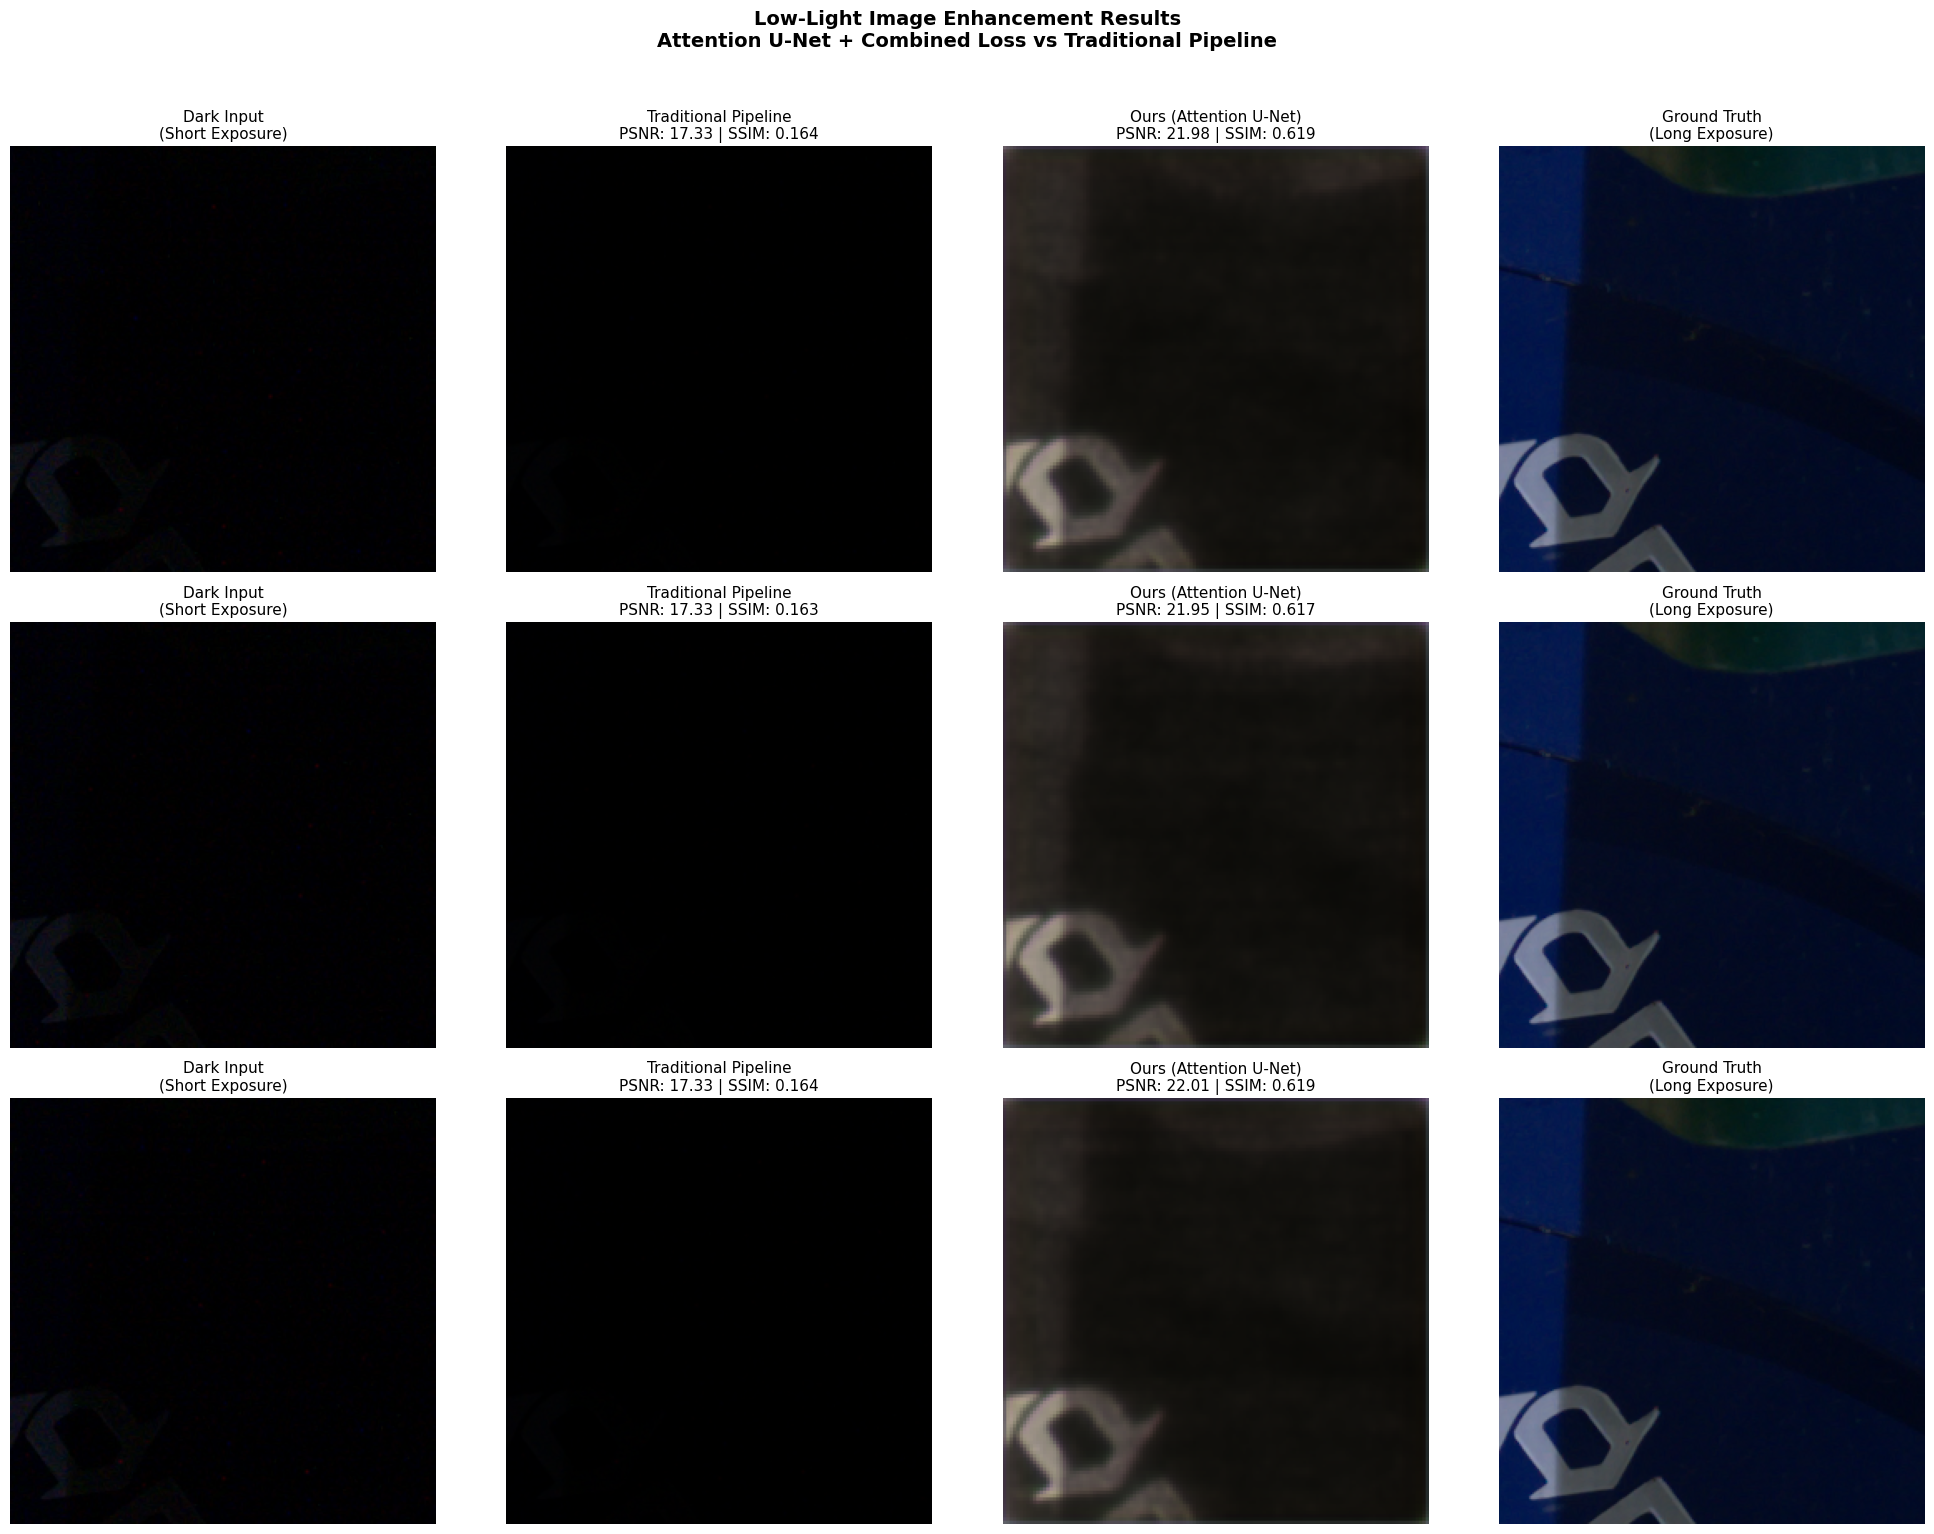


         QUANTITATIVE RESULTS SUMMARY
Method                     PSNR (dB)       SSIM
-------------------------------------------------------
Traditional Pipeline           17.33      0.164
Ours (Attn U-Net)              21.98      0.618
-------------------------------------------------------
Improvement                    +4.65     +0.455

Comparison image saved to /content/comparison_results.png


In [ ]:
# COMPARISON BLOCK: Visual results for professor
import numpy as np
import matplotlib.pyplot as plt
import rawpy, os
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def traditional_pipeline(short_path, ratio):
    """Simulate traditional pipeline - just amplify raw"""
    raw   = rawpy.imread(short_path)
    img   = raw.postprocess(
                use_camera_wb=True,
                half_size=False,
                no_auto_bright=True,
                output_bps=16)
    img   = np.float32(img / 65535.0)
    img   = np.clip(img * (ratio / 100.0), 0, 1)
    return img

def our_result(short_path, long_path):
    """Our Attention U-Net result"""
    se    = float(os.path.basename(short_path).split('_')[-1][:-5])
    le    = float(os.path.basename(long_path).split('_')[-1][:-5])
    ratio = min(le / se, 300)

    raw   = rawpy.imread(short_path)
    inp   = np.clip(pack_raw(raw) * ratio, 0, 1)

    # Take center crop for inference
    H, W  = inp.shape[:2]
    cy, cx = H//2, W//2
    hps   = 128 // 2
    patch = inp[cy-hps:cy+hps, cx-hps:cx+hps, :]
    patch = np.expand_dims(patch, 0)

    pred  = model.predict(patch, verbose=0)[0]
    return pred

def get_gt(long_path):
    """Get ground truth"""
    raw = rawpy.imread(long_path)
    gt  = np.float32(raw.postprocess(
              use_camera_wb=True,
              half_size=False,
              no_auto_bright=True,
              output_bps=16) / 65535.0)
    return gt

# ── Plot 3 test images ───────────────────────────────────────
n_show = min(3, len(test_pairs))
fig, axes = plt.subplots(n_show, 4, figsize=(20, 5*n_show))
fig.suptitle('Low-Light Image Enhancement Results\n'
             'Attention U-Net + Combined Loss vs Traditional Pipeline',
             fontsize=14, fontweight='bold', y=1.02)

psnr_ours = []
psnr_trad = []
ssim_ours = []
ssim_trad = []

for idx in range(n_show):
    sp, lp = test_pairs[idx]

    se     = float(os.path.basename(sp).split('_')[-1][:-5])
    le     = float(os.path.basename(lp).split('_')[-1][:-5])
    ratio  = min(le / se, 300)

    # Get results
    trad   = traditional_pipeline(sp, ratio)
    ours   = our_result(sp, lp)
    gt     = get_gt(lp)

    # Crop GT to match our output size (256x256)
    H, W   = gt.shape[:2]
    cy, cx = H//2, W//2
    gt_crop = gt[cy-128:cy+128, cx-128:cx+128, :]

    # Crop trad to match
    trad_crop = trad[cy-128:cy+128, cx-128:cx+128, :]

    # Raw dark input visualization
    raw_vis  = rawpy.imread(sp)
    raw_img  = np.float32(raw_vis.postprocess(
                   use_camera_wb=True,
                   half_size=False,
                   no_auto_bright=True,
                   output_bps=16) / 65535.0)
    raw_crop = raw_img[cy-128:cy+128, cx-128:cx+128, :]
    raw_crop = np.clip(raw_crop * 5, 0, 1)  # slightly boost to show it's dark

    # Compute metrics
    p_ours = psnr(gt_crop, ours,   data_range=1.0)
    p_trad = psnr(gt_crop, trad_crop, data_range=1.0)
    s_ours = ssim(gt_crop, ours,   data_range=1.0, channel_axis=2)
    s_trad = ssim(gt_crop, trad_crop, data_range=1.0, channel_axis=2)

    psnr_ours.append(p_ours)
    psnr_trad.append(p_trad)
    ssim_ours.append(s_ours)
    ssim_trad.append(s_trad)

    # Plot
    ax = axes[idx] if n_show > 1 else axes
    ax[0].imshow(raw_crop)
    ax[0].set_title('Dark Input\n(Short Exposure)', fontsize=11)
    ax[0].axis('off')

    ax[1].imshow(np.clip(trad_crop, 0, 1))
    ax[1].set_title(f'Traditional Pipeline\nPSNR: {p_trad:.2f} | SSIM: {s_trad:.3f}', fontsize=11)
    ax[1].axis('off')

    ax[2].imshow(np.clip(ours, 0, 1))
    ax[2].set_title(f'Ours (Attention U-Net)\nPSNR: {p_ours:.2f} | SSIM: {s_ours:.3f}', fontsize=11)
    ax[2].axis('off')

    ax[3].imshow(np.clip(gt_crop, 0, 1))
    ax[3].set_title('Ground Truth\n(Long Exposure)', fontsize=11)
    ax[3].axis('off')

plt.tight_layout()
plt.savefig('/content/comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ────────────────────────────────────────────
print("\n" + "="*55)
print("         QUANTITATIVE RESULTS SUMMARY")
print("="*55)
print(f"{'Method':<25} {'PSNR (dB)':>10} {'SSIM':>10}")
print("-"*55)
print(f"{'Traditional Pipeline':<25} {np.mean(psnr_trad):>10.2f} {np.mean(ssim_trad):>10.3f}")
print(f"{'Ours (Attn U-Net)':<25} {np.mean(psnr_ours):>10.2f} {np.mean(ssim_ours):>10.3f}")
print("-"*55)
print(f"{'Improvement':<25} {np.mean(psnr_ours)-np.mean(psnr_trad):>+10.2f} {np.mean(ssim_ours)-np.mean(ssim_trad):>+10.3f}")
print("="*55)
print("\nComparison image saved to /content/comparison_results.png")